# Training the embeddings and what their code means
For GNNs, I split them up into a few variations, each of which read in our circuit QASM files, cleaned, augmented, and defined the data in different ways (more explination below), then trained embeddings on that data, capturing the contrastive loss
1. a basic autoencoder using TransformerConv, following the ideas from https://medium.com/stanford-cs224w/graph-transformer-for-node-label-prediction-with-pyg-87a6b14f3ee9
2. a GraphCL-style self-supervised learning pipeline that trains GCN/GAT/GraphSAGE encoders with contrastive learning (via augmented graph views and InfoNCE loss), following the ideas from https://arxiv.org/html/2604.23700v1 and their thoughts on learning through augmentation of circuits.
3. a GraphCL-style self-supervised learning pipeline that trains GCN/GAT/GraphSAGE encoders with contrastive learning (via augmented graph views, embedding normalization, and InfoNCE loss), following the ideas from https://arxiv.org/html/2604.23700v1 and their thoughts on learning through augmentation of circuits.
4. a GraphCL‑style self‑supervised learning pipeline that trains GCN/GAT/GraphSAGE encoders with contrastive learning (via enriched gate‑and‑structure‐aware graph views, embedding normalization and InfoNCE loss), following the ideas from https://arxiv.org/html/2604.23700v1 and their thoughts on learning through augmentation of circuits and the information through IBM qickit (https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.dagcircuit.DAGCircuit) and their learn quantum computing courses.

A large amount of time went into researching these with reading, trail and error, AI for bugs I couldn't seem to figure out, and iterative testing.
I feel like these were good attempts for the first time really dealing with graph data and GNNs.

these scripts are located in the embedding_generation_scripts directory in the same directory this ipynb is in.

# Let's look at the embeddings
Now we're at the point where graph embeddigns have been generated (took 6+ hours on my computer to do so)
While doing so I captured the contrastive loss (idea from https://medium.com/@mlshark/infonce-explained-in-details-and-implementations-902f28199ce6) to use as a metric to determine when to determine when the embeddings weren't making any more progress while training.
These files are stored at data/datasets/embedding_data/loss . 

Let's take a look at the losses and if there are any that stand out

## Reaction to loss vs eposh results
Not super suprising to me that the more complex and fine tuned representations of the qasm files have lower loss scores.

What is suprising to me is that the very basic graph autoencoder (gae) scored the middle of the pack (5th out of 10)

--> More on that later

# How I intend to "judge these embeddings"

This doesn't feel very informative yet, but I'm going to use that K-Means, GMM, and HDBSCAN because they each act as different “lenses” on the created embedding spaces, helping me to validate whether the embeddings might contain meaningful structure ... or if it's just noise.
These embeddings are high-dimensional vectors where semantic similarity is supposed to correspond to geometric proximity. So I'm hoping that the clustering algorithms are a practical way to test whether that geometry is organized in a way that reflects real groupings, especially given that each method checks a different kind of assumption about the structure.

Why these three?

* K-Means Clustering:
    * Why it's unique: it forces the embeddigs into centroid-based partitions that test the global separability.
    * Pros: It's fast, scalable, and can be interpreted pretty easilly via the cluster centroids.
    * Cons: It requires predefining the k number of clusters and assumes spherical clusters.
    * Limitations: It can over-simplify complex or overlapping semantic structure (what about elliptical shaped clusters?) and assigns every point to a cluster with no noise handling.

* Gaussian Mixture Model (GMM):
    * Why it's unique: it models embeddings as overlapping probabilistic groups, helping to capture soft or unique semantic boundaries.
    * Pros: it allows probabilistic membership and flexible unique (e.g. elliptical) cluster shapes.
    * Cons: it assumes Gaussian-distributed clusters and is computationally heavier than K-Means.
    * Limitations: it struggles with non-Gaussian or irregular structures and still requires choosing number of components.

* HDBSCAN:
    * Why it's unique: it calculates natural density-based groupings while explicitly identifying noise in the embedding space.
    * Pros: there's no need set number of clusters and can detect arbitrarily shaped clusters.
    * Cons: it is pretty sensitive to hyperparameters like minimum cluster size and can produce unstable cluster boundaries.
    * Limitations: with high-dimensional embedding spaces it's hard to tune and can provide a less globally consistent structure.

# K-Means Clustering - evaluating k using silhouette score
First let's tackle the K-Means Clustering. 

As the title to this cell implies, I'm using evaluating k using silhouette score. But what is a silhouette score? 
I'm going to paraphrase https://www.geeksforgeeks.org/machine-learning/what-is-silhouette-score/ as it's been a really helpful website for me over the past few years:
* A Silhouette Score measures how well each data point fits within its assigned cluster compared to the other clusters. It uses the average distance to points in the same cluster and compares those to the nearest neighboring cluster to determine separation and cohesion. The score ranges from -1 to +1, where higher values indicate better-defined and well-separated clusters and lower values suggest overlap or misclassification.



### Below is a notebook equivalent of my k-means cluster pipeling script
#### Here are the relevant decisions I made while creating the script:
* merged datasets on the file column, to ensure that the embedding vector is correctly aligned with its metadata so clustering and later evaluation (e.g., ARI) are consistent and comparable across runs.
* selected the embedding columns using the emb_* prefix rule from when i created the embedding CSVs to automatically include all features in the learned representation without any manual feature engineering
* applied L2 normalization, scaling each embedding vector to unit length so clustering is driven by the direction / similarity, rather than raw magnitude
* ran KMeans with n_init=20, meaning each clustering solution is initialized 20 times and the best solution is then chosen for stability
* used a random seed of random_state=42, making results hopefully reproducible across runs
* searched over k values from 3 to 21 (just some arbitrarily large number, as I could not find any hard and fast rule), meaning k was tested 17 different cluster configurations to find the best structure
* selected the optimal k using silhouette score, which measures how well-separated clusters are with higher = tighter, more distinct clusters. score goes from -1 to 1.
* computed silhouette scores for every k in the range and chose the maximum score as the final model selection criterion
* computed distance-to-centroid (minimum Euclidean distance) per point, where smaller values indicate stronger cluster membership confidence
* projected embeddings to 2D using PCA (n_components=2) only for visualization, preserving interpretability without affecting the clustering itself
* generated a silhouette curve over to visually inspect how clustering quality changes with k and model complexity
* generated cluster summaries over 3 hardware aware metrics, using count/mean/std/min/max to characterize how each cluster differs in behavior
* structured outputs into three layers: full dataset (main_df), inference view (file + cluster + distance), and summary tables for experiment tracking
* returned plots as objects in a dictionary so they can be displayed at execution time while in this notebook

In [3]:
# import needed libs / packages
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
# pipeline function that should work here
def run_kmeans_pipeline(swap_path, embedding_path, PCA_VAL=False):
    """
    kmeans clustering pipeline with silhouette-based k selection.

    this function builds a full clustering workflow over embedding data:
    - loads swap and embedding datasets and merges them on file id
    - enforces strict alignment for reproducibility (important for ari comparisons)
    - extracts embedding features and cleans missing rows
    - normalizes feature vectors (l2 normalization)
    - optionally reduces dimensionality using pca
    - selects optimal k using silhouette score over a fixed range
    - fits final kmeans model using best k
    - assigns clusters and computes distance-to-centroid scores
    - generates diagnostic plots and summary metrics
    - exports all artifacts for downstream analysis

    parameters
    ----------
    swap_path : str
        path to swap dataset (csv)

    embedding_path : str
        path to embedding dataset (csv)

    PCA_VAL : bool
        if true, applies pca (90% variance retained), otherwise skips it

    returns
    -------
    main_df : pd.DataFrame
        full dataset including cluster assignments and diagnostics

    output_df : pd.DataFrame
        minimal inference-ready view (file, cluster, distance)

    summary_df : pd.DataFrame
        run-level summary (best k, silhouette score, feature stats)
    """

    ###############################################
    # load + align data (critical for ari consistency)
    ###############################################
    # read teh raw inputs
    swap_df = pd.read_csv(swap_path)
    embedding_df = pd.read_csv(embedding_path)

    # merge on file identifier col to ensure row alignment
    base_df = swap_df.merge(embedding_df, on="file", how="inner")

    # identify the embedding feature columns
    emb_features = base_df.filter(regex=r"^emb_").columns.tolist()

    # drop rows with missing embedding values to avoid instability
    # should not be any, but just in case
    base_df = base_df.dropna(subset=emb_features).reset_index(drop=True)

    ###############################################
    # create the embeddings matrix
    ###############################################
    # convert embedding columns into np matrix
    X = base_df[emb_features].to_numpy(dtype=float)

    ###############################################
    # normalization
    ###############################################
    # l2 normalization via sklearn to improve kmeans distance behavior
    X = normalize(X)

    ###############################################
    # PCA - optional and no longer needed
    ###############################################
    # this is a holdover from when we were testing with our
    # calculated results vs the qasm files themselves, False by default now
    if PCA_VAL == True:
        pca = PCA(n_components=0.90, random_state=42)
        X_used = pca.fit_transform(X)
    else:
        X_used = X

    ###############################################
    # silhouette search for best k
    ###############################################

    k_range = range(2, 21)

    scores = []
    best_k = None
    best_score = -1
    best_model = None

    # evaluate kmeans for multiple k values, using silhouette score as the judge
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=20)

        labels = km.fit_predict(X_used)

        # silhouette score measures cluster separation quality
        score = silhouette_score(X_used, labels)
        scores.append(score)

        # keep track best performing model
        if score > best_score:
            best_score = score
            best_k = k
            best_model = km

    ###############################################
    # final model output
    ###############################################
    # assign the final cluster labels
    labels = best_model.predict(X_used)
    # calculate the distance to nearest centroid to help determine confidence
    distances = best_model.transform(X_used)
    
    base_df = pd.concat(
        [
            base_df,
            pd.DataFrame({
                "kmeans_cluster": labels,
                "kmeans_distance": distances.min(axis=1)
            }, index=base_df.index)
        ],
        axis=1
    )

    ###############################################
    # 2d visualization
    ###############################################
    figures = {}
    
    # project the high-dim embeddings into 2d for visualization to see shape
    # for setup, i follow ideas from: https://www.geeksforgeeks.org/machine-learning/k-means-clustering-introduction/
    X_2d = PCA(n_components=2, random_state=42).fit_transform(X)

    fig1 = plt.figure(figsize=(10, 7))

    sns.scatterplot(
        x=X_2d[:, 0],
        y=X_2d[:, 1],
        hue=base_df["kmeans_cluster"],
        palette="tab10",
        s=40,
        alpha=0.7,
    )

    plt.title(f"KMeans Clusters (K={best_k})")
    plt.tight_layout()
    figures["kmeans_cluster"] = fig1
    plt.close()

    ###############################################
    # silhouette curve
    ###############################################
    # visualize how the silhouette score changes with k
    fig2 = plt.figure(figsize=(8, 5))
    plt.plot(list(k_range), scores, marker="o")
    plt.xlabel("K")
    plt.ylabel("Silhouette Score")
    plt.title("KMeans Silhouette Search")
    plt.grid(True)
    figures["kmeans_silhouette_curve"] = fig2
    plt.close()

    ###############################################
    # metrics analysis
    # metrics defined by our teams research as important for the non-polarized dataset
    ###############################################
    # use important metrics to summarize per cluster
    metrics = ["bare_routed_2q", "bare_routed_depth", "mirror_over_bare_2q"]

    metric_rows = []

    # compute the cluster-level statistics for each metric
    for m in metrics:
        grouped = (
            base_df.groupby("kmeans_cluster")[m]
            .agg(["count", "mean", "std", "min", "max"])
            .reset_index()
        )

        grouped["metric"] = m
        metric_rows.append(grouped)

    metric_df = pd.concat(metric_rows, ignore_index=True)

    ###############################################
    # create a summary df
    ###############################################
    # summary for logging and tracking for the code run
    summary_df = pd.DataFrame(
        [
            {
                "best_k": best_k,
                "silhouette": best_score,
                "n_samples": len(base_df),
                "n_features": len(emb_features),
                "pca_dims": X_used.shape[1],
            }
        ]
    )

    ###############################################
    # create the full output for all out computed data
    ###############################################
    # save the full enriched dataset for possible analysis and debugging
    main_df = base_df.copy()

    ###############################################
    # pipeline output view (for ari)
    ###############################################
    # create a minimal view used for clustering comparison metric ari
    output_df = base_df[["file", "kmeans_cluster", "kmeans_distance"]].copy()

    ###############################################
    # return the created dfs
    ###############################################
    return main_df, output_df, summary_df, metric_df, figures

In [5]:
# run the pipeline with the swap circuit file and embedding file path
from pathlib import Path
notebook_dir = Path.cwd()

SWAP_PATH = (notebook_dir / "../../data/datasets/train_swap_FakeBrisbane.csv").resolve()
EMBEDDING_PATH = (notebook_dir / "../../data/datasets//embedding_data/embeddings/graphsage_aug_dropout_and_norm_with_improved_edges_training.csv").resolve()

kmeans_main_df, kmeans_output_df, kmeans_summary_df, kmeans_metric_df, kmeans_figures = run_kmeans_pipeline(
    SWAP_PATH,
    EMBEDDING_PATH
)

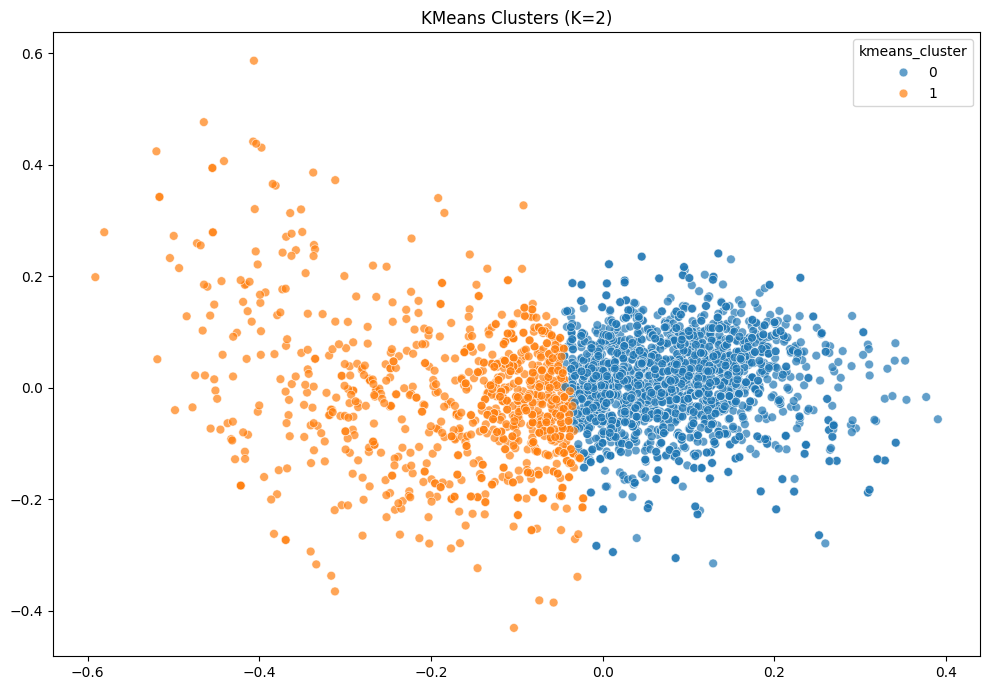

In [5]:
kmeans_figures["kmeans_cluster"]

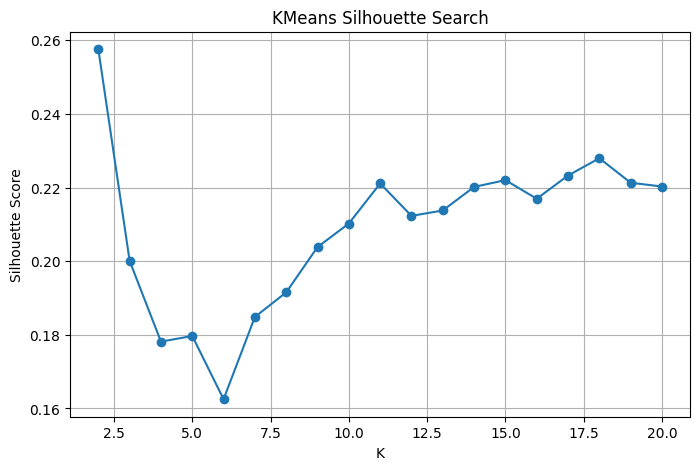

In [6]:
# global best k for graphsage_aug_dropout_and_norm_with_improved_edges_training.csv embedding
# via 
kmeans_figures["kmeans_silhouette_curve"]

In [7]:
#kmeans_summary_df

In [8]:
#kmeans_output_df.sample(20)

In [9]:
kmeans_metric_df

,kmeans_cluster,count,mean,std,min,max,metric
0,0,1862,265.454350,264.582751,0.000000,3306.000000,bare_routed_2q
1,1,965,123.583420,102.297024,0.000000,1278.000000,bare_routed_2q
2,0,1862,474.683673,426.881300,6.000000,4819.000000,bare_routed_depth
3,1,965,244.377202,194.078669,4.000000,2961.000000,bare_routed_depth
4,0,1861,2.009329,0.116784,1.361111,2.473154,mirror_over_bare_2q
5,1,963,1.988019,0.200238,0.521739,2.769231,mirror_over_bare_2q


In [10]:
#kmeans_main_df["kmeans_cluster"].value_counts().sort_index()

## Interesting results for k-means on the lowest loss embedding
To keep things a little shorter, no what I was expecting.

Our lowest contrastive loss embedding is split quite evenly accross our circuit hardware aware features (bare_routed_2q, bare_routed_depth, mirror_over_bare_2q). 

initial observations of via the metric df:
1. cluster 0 (large/high-complexity group): captures the majority of higher-complexity circuits (~265 2q, ~475 depth) but with very large variance, meaning KMeans is grouping a wide spectrum of complex circuits into one broad bucket rather than splitting structure finely
2. cluster 1 (low-to-mid complexity group): smaller, tighter group (~123 2q, ~244 depth), representing more “lightweight” circuits with noticeably less structural spread than cluster 0
3. overall split (0 vs 1): KMeans is essentially learning a binary complexity axis (high vs low), rather than multiple nuanced regimes like GMM or HDBSCAN
4. within-cluster variance (especially cluster 0): extremely high std (e.g., ~264 for 2q, ~426 for depth) suggests strong overlap of multiple hidden subgroups that KMeans is collapsing together
5. mirror_over_bare_2q (both clusters): nearly identical means (~2.01 vs ~1.99) and overlapping ranges, showing this feature is not contributing meaningfully to separation

So it looks like KMeans is behaving like a coarse global partitioner, mainly splitting the dataset by circuit size/depth while ignoring finer structural or behavioral distinctions

It seems like it's pretty good, but maybe there's one that's better? but how do we get to it? 

I think Adjusted Rand Index (ARI) would be a good method per sklearn (https://scikit-learn.org/stable/auto_examples/cluster/plot_adjusted_for_chance_measures.html) as it allows us to compare the similarity between two clusterings, making it a robust and more reliable than raw accuracy-style comparisons for unsupervised clustering evaluation.

We'll get back to that after we set up GMM and HDBSCAN

# Gaussian Mixture Model (GMM) - Using Bayesian Information Criterion (BIC) for model selection

As the title to this cell implies, I'm using evaluating GMM model selection using BIC. But what is a BIC? 
Before googleing "automated gmm model selection" and comming accross the NIH paper "Bayesian feature and model selection for Gaussian mixture models" (https://pubmed.ncbi.nlm.nih.gov/16724595/), I had no idea. 
* Essentially, BIC is a metric used to compare statistical models by balancing how well a model fits the data against how complex it is. It penalizes models with more parameters to help avoid overfitting. Lower BIC values indicate a better model relative to others being compared.

### Below is a notebook equivalent of my GMM via BIC pipeling script
#### Here are the relevant decisions I made while creating the script:

* merged datasets on the file column, to ensure that the embedding vector is correctly aligned with its metadata so clustering and later evaluation (e.g., ARI) are consistent and comparable across runs.
* selected the embedding columns using the emb_* prefix rule from when i created the embedding CSVs to automatically include all features in the learned representation without any manual feature engineering
* applied L2 normalization, scaling each embedding vector to unit length so clustering is driven by the direction / similarity, rather than raw magnitude
* fixed covariance structure to diag, assuming feature independence within clusters to improve stability and scalability in high-dimensional embedding space.
* searched over k = 2 to 20 (18 total configurations) to explore a wide range of cluster granularities and avoid predefining the number of latent groups.
* used BIC (Bayesian Information Criterion) as the selection rule, choosing the model with the lowest BIC to balance fit quality against model complexity.
* set n_init=20, meaning each GMM configuration is fit 20 times with different initializations to reduce sensitivity to local optima in EM optimization.
* used random_state=42 to make initialization and model selection reproducible across runs.
* assigned clusters using predict() and computed confidence using the maximum posterior probability per sample (predict_proba().max(axis=1)), where higher values indicate stronger cluster membership certainty.
* computed silhouette score as a diagnostic metric (not used for selection), where values closer to 1 indicate better-separated clusters and values near 0 or negative indicate overlap or poor structure.
* projected embeddings into 2D using PCA (n_components=2) strictly for visualization purposes, preserving interpretability without influencing clustering results.
* generated a BIC curve over all tested k values to visually inspect how model complexity impacts fit and confirm the selected optimum.
* aggregated cluster-level statistics over domain-specific metrics (bare_routed_2q, bare_routed_depth, mirror_over_bare_2q) using count/mean/std/min/max to interpret behavioral differences between clusters.
* structured outputs into multiple layers: main_df (full enriched dataset), output_df (minimal inference/ARI view with file + cluster + confidence), and summary_df (run-level metadata for experiment tracking).
* returned figures as a dictionary of matplotlib objects so they can be rendered interactively in notebook or pipeline execution contexts.

In [11]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [12]:
def run_gmm_pipeline(swap_path, embedding_path, PCA_VAL=False):
    """
    GMM clustering pipeline with BIC-based model selection.

    This pipeline:
    - merges swap + embedding data
    - ensures strict row alignment for cross-method comparison (ARI-safe)
    - normalizes embeddings
    - applies PCA --> no longer done!
    - selects best GMM via BIC
    - assigns soft + hard cluster labels
    - exports cluster outputs + summaries + plots

    Returns
    -------
    main_df : pd.DataFrame
        Full dataset with GMM assignments.

    output_df : pd.DataFrame
        Lightweight inference-style output.

    summary_df : pd.DataFrame
        Run-level metrics.
    """

    ###############################################
    # load and align data (needed for ARI evaluation)
    ###############################################
    # read in the csv files
    swap_df = pd.read_csv(swap_path)
    embedding_df = pd.read_csv(embedding_path)

    # merge on file identifier col to ensure row alignment
    base_df = swap_df.merge(embedding_df, on="file", how="inner")

    # identify the embedding feature columns
    emb_features = base_df.filter(regex=r"^emb_").columns.tolist()

    # drop rows with missing embedding values to avoid instability
    # should not be any, but just in case
    base_df = base_df.dropna(subset=emb_features).reset_index(drop=True)

    ###############################################
    # embedding matrix extraction
    ###############################################
    # convert embedding columns into np matrix
    X = base_df[emb_features].to_numpy(dtype=float)

    ###############################################
    # NORMALIZATION
    ###############################################
    # l2 normalization via sklearn to improve kmeans distance behavior
    X = normalize(X)

    ###############################################
    # PCA - optional and no longer needed
    ###############################################
    # this is a holdover from when we were testing with our
    # calculated results vs the qasm files themselves, False by default now
    if PCA_VAL == True:
        pca = PCA(n_components=0.90, random_state=42)
        X_used = pca.fit_transform(X)
    else:
        X_used = X

    ###############################################
    # gmm model selection using bic
    ###############################################
    # try multiple cluster sizes and select best via lowest bic
    n_components_range = range(2, 20)

    bics = []
    best_gmm = None
    best_bic = np.inf
    best_k = None

    for k in n_components_range:
        # covariance_type
            # was using full ... needs more testing
            # diag (most common for embeddings)
            # tied (often more stable)
            # spherical (very robust baseline)
        gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42, n_init=20)

        gmm.fit(X_used)
        bic = gmm.bic(X_used)

        bics.append(bic)

        # keep best performing model
        if bic < best_bic:
            best_bic = bic
            best_gmm = gmm
            best_k = k

    ###############################################
    # final model inference
    ###############################################
    # assign the hard clusters and confidence scores
    labels = best_gmm.predict(X_used)
    probs = best_gmm.predict_proba(X_used).max(axis=1)

    base_df = base_df.copy()
    base_df["gmm_cluster"] = labels
    base_df["gmm_prob"] = probs

    ###############################################
    # silhouette score - might not use, but good to have
    ###############################################
    # not used for selection here
    # measures cluster separation quality
    sil = silhouette_score(X_used, labels)

    ###############################################
    # 2d visualization
    ###############################################
    figures = {}
    
    # just like k-means clustering script,
    # project the high-dim embeddings into 2d for visualization to see shape
    # for setup, follow ideas from: https://www.geeksforgeeks.org/machine-learning/k-means-clustering-introduction/
    X_2d = PCA(n_components=2, random_state=42).fit_transform(X)

    fig1 = plt.figure(figsize=(10, 7))

    sns.scatterplot(
        x=X_2d[:, 0],
        y=X_2d[:, 1],
        hue=base_df["gmm_cluster"],
        palette="tab10",
        s=40,
        alpha=0.7,
    )

    plt.title(f"GMM Clusters (K={best_k})")
    plt.tight_layout()
    figures["gmm_cluster"] = fig1    
    plt.close()

    ###############################################
    # silhouette curve
    ###############################################
    # visualize how the silhouette score changes with k
    fig2 = plt.figure(figsize=(8, 5))
    plt.plot(list(n_components_range), bics, marker="o")
    plt.xlabel("n_components")
    plt.ylabel("BIC")
    plt.title("BIC n_components Search")
    plt.grid(True)
    figures["GMM_BIC_curve"] = fig2
    plt.close()
    
    ###############################################
    # metrics analysis
    # metrics defined by our teams research as important for the non-polarized dataset
    ###############################################
    # use important metrics to summarize per cluster
    metrics = ["bare_routed_2q", "bare_routed_depth", "mirror_over_bare_2q"]

    metric_rows = []

    for m in metrics:
        grouped = (
            base_df.groupby("gmm_cluster")[m]
            .agg(["count", "mean", "std", "min", "max"])
            .reset_index()
        )

        grouped["metric"] = m
        metric_rows.append(grouped)

    metric_df = pd.concat(metric_rows, ignore_index=True)

    ###############################################
    # create a summary df
    ###############################################
    # summary for logging and tracking for the code run

    summary_df = pd.DataFrame(
        [
            {
                "best_k": best_k,
                "bic": best_bic,
                "silhouette": sil,
                "n_samples": len(base_df),
                "n_features": len(emb_features),
                "pca_dims": X_used.shape[1],
            }
        ]
    )
    ###############################################
    # create the full output for all out computed data and save to csv
    ###############################################
    # save the full enriched dataset for possible analysis and debugging

    main_df = base_df.copy()
    ###############################################
    # pipeline output view (for ari)
    ###############################################
    # create a minimal view used for clustering comparison metric ari

    output_df = base_df[["file", "gmm_cluster", "gmm_prob"]].copy()
    ###############################################
    # return the created dfs
    ###############################################

    return main_df, output_df, summary_df, metric_df, figures

In [13]:
# run the pipeline with the swap circuit file and embedding file path
from pathlib import Path
notebook_dir = Path.cwd()

SWAP_PATH = (notebook_dir / "../../data/datasets/train_swap_FakeBrisbane.csv").resolve()
EMBEDDING_PATH = (notebook_dir / "../../data/datasets//embedding_data/embeddings/graphsage_aug_dropout_and_norm_with_improved_edges_training.csv").resolve()

gmm_main_df, gmm_output_df, gmm_summary_df, gmm_metric_df, gmm_figures = run_gmm_pipeline(
    SWAP_PATH,
    EMBEDDING_PATH
)

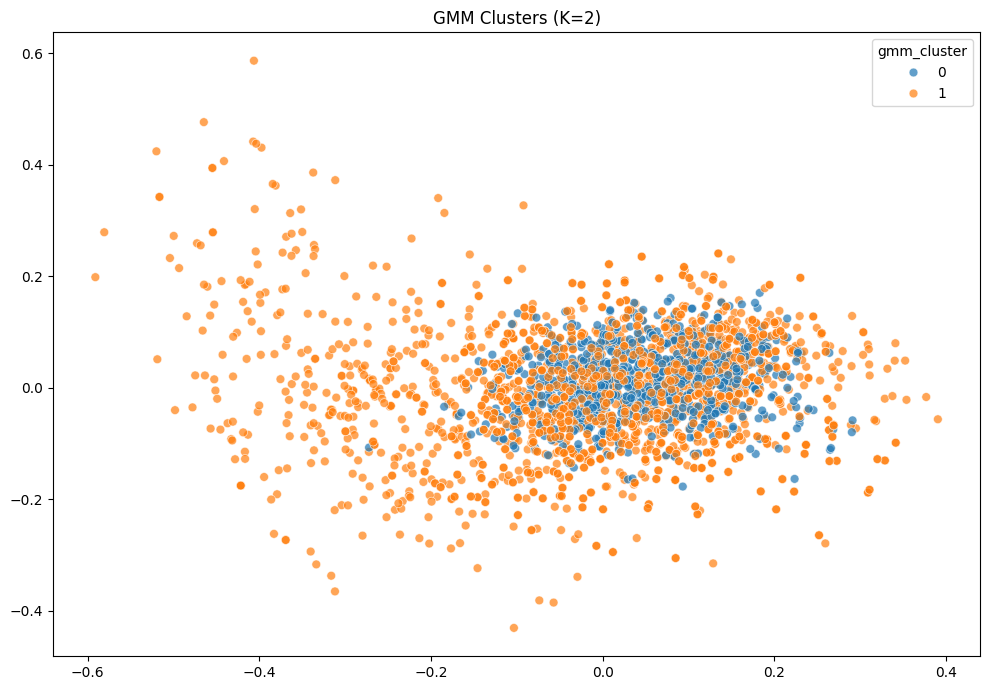

In [14]:
gmm_figures["gmm_cluster"]

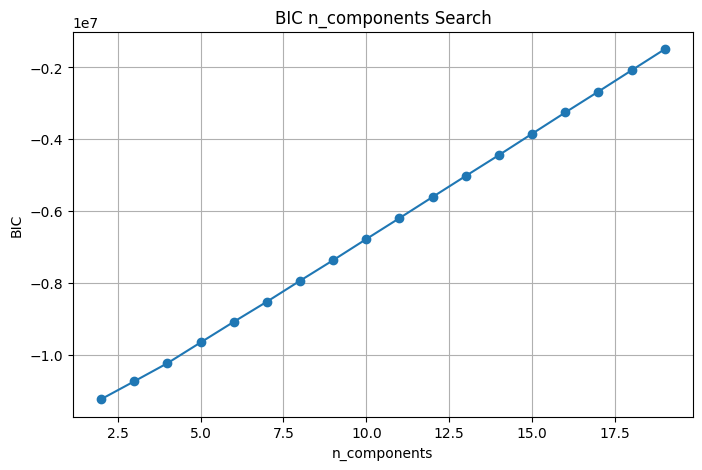

In [15]:
gmm_figures["GMM_BIC_curve"]

In [16]:
gmm_metric_df.head(203)

,gmm_cluster,count,mean,std,min,max,metric
0,0,754,270.383289,379.201584,0.000000,3306.000000,bare_routed_2q
1,1,2073,197.619392,142.296052,0.000000,828.000000,bare_routed_2q
2,0,754,501.618037,634.006470,6.000000,4819.000000,bare_routed_depth
3,1,2073,357.677279,214.140976,4.000000,1251.000000,bare_routed_depth
4,0,753,1.998188,0.144120,1.361111,2.473154,mirror_over_bare_2q
5,1,2071,2.003471,0.153214,0.521739,2.769231,mirror_over_bare_2q


## Interesting results for GMM on the lowest loss embedding

Here, instead of having two clear clusters, our lowest contrastive loss embedding is split quite seemingly erratically accross our circuit hardware aware features (bare_routed_2q, bare_routed_depth, mirror_over_bare_2q). The gmm_metric_df seems to confirm that the clusters aren't well seperated.

This doesn't really seem like a useful result to me, but here are some observations going through the metric data:
1. Cluster 0 (high-complexity regime): This cluster contains the more complex circuits in the dataset, with an average of approximately 270 routed two-qubit gates and a depth of about 502. The large standard deviations indicate that it encompasses a broad range of medium- to extremely high-complexity circuits, rather than representing a single, tightly defined group.
2. Cluster 1 (main operating regime): This cluster contains the majority of the circuits, with an average of approximately 198 routed two-qubit gates and a depth of about 358. Compared to Cluster 0, it exhibits considerably lower variance, suggesting that it represents the primary and more homogeneous operating regime of the dataset.
3. Reduced complexity hierarchy: In contrast to the previous diagonal-covariance GMM, which divided the embedding space into multiple low-, medium-, and high-complexity groups, the full-covariance model merges these into two broad clusters. This indicates that many of the previously identified subclusters were likely capturing covariance structure rather than distinct circuit families.
4. Correlation between size and depth: Allowing full covariance enables the GMM to model the strong correlation between routed two-qubit gate count and circuit depth within each cluster. As a result, fewer Gaussian components are required to represent the data, leading to broader but more flexible clusters.
5. Mirror-to-bare 2Q ratio: The mirror_over_bare_2q metric remains nearly identical across both clusters (approximately 2.0), with only minor variation. As before, this metric contributes little to the clustering, indicating that circuit size and depth remain the primary factors driving cluster separation.

it looks like GMM merging many of those overlapping groups into just two broad distributions because each Gaussian can now model correlations between features (especially routed 2Q count and depth).

Once again, this is just an example, we're going to run the full pipeline and get more meaningful figures and tables and run ARI after we have the three modeling functions

# HDBSCAN


### Below is a notebook equivalent of my HDBSCAN pipeling script
#### Here are the relevant decisions I made while creating the script:

* merged datasets on file to ensure embeddings + metadata are aligned for valid clustering + ARI consistency across runs
* selected embedding columns via emb_* prefix to automatically include all learned GNN features without manual feature engineering
* applied L2 normalization to scale vectors to unit length, making Euclidean distance behave like cosine similarity in embedding space
* set PCA(n_components=0.90) when enabled to retain 90% variance, otherwise kept full embedding space for clustering
* used HDBSCAN (density-based, no fixed k) to discover variable-sized clusters and naturally handle outliers via noise label -1
* set min_cluster_size=28 to avoid tiny unstable clusters and bias toward meaningful semantic groupings (~1% heuristic of dataset)
* set min_samples=10 to make clustering more conservative, increasing noise labeling for ambiguous boundary points
* used metric="euclidean" assuming normalized embeddings make L2 distance a valid similarity proxy
* used cluster_selection_method="eom" to prioritize stable clusters that persist across density levels rather than fine-grained splits
* computed cluster probability scores (0–1) via HDBSCAN to quantify assignment confidence per sample
* computed cluster metrics (count/mean/std/min/max) over 3 domain features to quantify behavioral differences per cluster
* separated noise (-1) vs clean clusters to explicitly analyze outlier structure instead of forcing assignment
* computed structural profiles over 11 graph features (e.g., fiedler_topology, graph_diameter) to interpret cluster semantics
* limited visualization to PCA 2D projection (n_components=2) purely for interpretability of high-dimensional embedding structure

In [17]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import hdbscan

from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

In [18]:
def run_hdbscan_pipeline(swap_path, embedding_path, PCA_VAL=False):
    """
    HDBSCAN clustering pipeline for embedding-based circuit analysis.

    This pipeline:
    - merges swap + embedding data
    - enforces strict row alignment (ARI-safe across methods)
    - normalizes embeddings
    - runs HDBSCAN clustering
    - computes cluster + noise statistics
    - produces structural summaries
    - saves outputs, plots, and metadata

    Returns
    -------
    main_df : pd.DataFrame
        Full dataset with HDBSCAN labels.

    output_df : pd.DataFrame
        Lightweight inference-style output.

    summary_df : pd.DataFrame
        Run-level metrics.
    """

    ###############################################
    # load and align data (needed for ARI evaluation)
    ###############################################
    # read in the csv files
    swap_df = pd.read_csv(swap_path)
    embedding_df = pd.read_csv(embedding_path)

    # merge on file identifier col to ensure row alignment
    base_df = swap_df.merge(embedding_df, on="file", how="inner")

    # identify the embedding feature columns
    emb_features = base_df.filter(regex=r"^emb_").columns.tolist()

    # drop rows with missing embedding values to avoid instability
    # should not be any, but just in case
    base_df = base_df.dropna(subset=emb_features).reset_index(drop=True)

    ###############################################
    # embedding matrix extraction
    ###############################################
    # convert embedding columns into np matrix
    X = base_df[emb_features].to_numpy(dtype=float)

    ###############################################
    # NORMALIZATION
    ###############################################
    # l2 normalization via sklearn to improve kmeans distance behavior
    X = normalize(X)

    ###############################################
    # PCA - optional and no longer needed
    ###############################################
    # this is a holdover from when we were testing with our
    # calculated results vs the qasm files themselves, False by default now
    if PCA_VAL == True:
        pca = PCA(n_components=0.90, random_state=42)
        X_used = pca.fit_transform(X)
    else:
        X_used = X

    ###############################################
    # hdbscan clustering (density-based method)
    ###############################################
    # hdbscan does not require predefined number of clusters (unlike kmeans/gmm)
    # but we do have to choose some numbers:

    # min_cluster_size=28:
    # tried to find a number that ensured the clusters weren't too small or noisy.
    # 1% of total datasize came up in a few posts, so I went with 28.
    # the hope is that using this for for gnn embeddings will help
    # avoid overfitting to any local density artifacts and to forces only
    # the meaningful, stable semantic groups to form
    
    # min_samples=10:
    # as i didn't want random small noise clusters, I chose 10, large enough
    # to prevent noise from taking over, but hopefully large enough to allow
    # meaningful groups to form. the thought is that higher values make 
    # clustering more conservative and increase noise labeling,
    # which is useful for gnn embeddings that often have fuzzy boundaries
    
    # metric="euclidean":
    # this assumes that euclidean distance is meaningful in embedding space;
    # combined with l2 normalization, it should approximate cosine similarity
    # and works well for GNN embeddings, since the embeddings are normalized
    # to unit length.
    
    # cluster_selection_method="eom":
    # honestly, this is the default, but it's description is worth mentioning:
    # The standard approach for HDBSCAN* is to use an Excess of Mass ("eom") 
    # algorithm to find the most persistent clusters. Alternatively you can instead 
    #select the clusters at the leaves of the tree – this provides the most 
    # fine grained and homogeneous clusters.
    # http://scikit-learn.org/stable/modules/generated/sklearn.cluster.HDBSCAN.html

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=28,
        min_samples=10,
        metric="euclidean",
        cluster_selection_method="eom",
    )

    # fit model and assign cluster labels
    labels = clusterer.fit_predict(X_used)
    # probability-like confidence score per point (0 to 1)
    probs = clusterer.probabilities_

    base_df = base_df.copy()
    base_df["hdbscan_cluster"] = labels
    base_df["hdbscan_prob"] = probs

    ###############################################
    # metrics analysis - cluster vs noise separation
    # metrics defined by our teams research as important for the non-polarized dataset
    ###############################################
    # label -1 corresponds to noise points (not assigned to any cluster)
    noise = base_df[base_df["hdbscan_cluster"] == -1]
    clean = base_df[base_df["hdbscan_cluster"] != -1]

    metrics = ["bare_routed_2q", "bare_routed_depth", "mirror_over_bare_2q"]

    metric_rows = []

    for m in metrics:
        # compute teh descriptive statistics per cluster
        grouped = (
            base_df.groupby("hdbscan_cluster")[m]
            .agg(["count", "mean", "std", "min", "max"])
            .reset_index()
        )

        grouped["metric"] = m
        metric_rows.append(grouped)

    metric_df = pd.concat(metric_rows, ignore_index=True)

    ###############################################
    # structural profiling of clusters
    ###############################################
    # these features describe graph / circuit topology behavior
    structural_cols = [
        "critical_depth",
        "program_communication",
        "parallelism",
        "fiedler_topology",
        "effective_resistance",
        "graph_density",
        "graph_diameter",
        "avg_clustering",
        "twoq_temporal_locality",
        "spectral_entropy_topology",
        "log_spanning_trees",
    ]

    # compute mean structural profile per cluster
    cluster_profile = (
        base_df.groupby("hdbscan_cluster")[structural_cols].mean().round(3)
    )

    ###############################################
    # 2d visualization
    ###############################################
    figures = {}
    
    # just like k-means clustering script,
    # project the high-dim embeddings into 2d for visualization to see shape
    # for setup, follow ideas from: https://www.geeksforgeeks.org/machine-learning/k-means-clustering-introduction/
    X_2d = PCA(n_components=2, random_state=42).fit_transform(X)

    fig1 = plt.figure(figsize=(10, 7))

    sns.scatterplot(
        x=X_2d[:, 0],
        y=X_2d[:, 1],
        hue=base_df["hdbscan_cluster"],
        palette="tab10",
        s=40,
        alpha=0.7,
    )

    plt.title("HDBSCAN Clusters (Embedding Space)")
    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    figures["hdbscan_clusters"] = fig1
    plt.close()

    ###############################################
    # create a summary df
    ###############################################
    # summary for logging and tracking for the code run
    summary_df = pd.DataFrame(
        [
            {
                "n_samples": len(base_df),
                "n_features": len(emb_features),
                "n_clusters": len(set(labels)) - (1 if -1 in labels else 0),
                "noise_points": len(noise),
                "noise_ratio": len(noise) / len(base_df),
            }
        ]
    )

    ###############################################
    # create the full output for all out computed data and save to csv
    ###############################################
    # save the full enriched dataset for possible analysis and debugging

    main_df = base_df.copy()

    ###############################################
    # pipeline output view (for ari)
    ###############################################
    # create a minimal view used for clustering comparison metric ari

    output_df = base_df[["file", "hdbscan_cluster", "hdbscan_prob"]].copy()

    ###############################################
    # return the created dfs
    ###############################################

    return main_df, output_df, summary_df, metric_df, figures

In [19]:
# run the pipeline with the swap circuit file and embedding file path
from pathlib import Path
notebook_dir = Path.cwd()

SWAP_PATH = (notebook_dir / "../../data/datasets/train_swap_FakeBrisbane.csv").resolve()
EMBEDDING_PATH = (notebook_dir / "../../data/datasets//embedding_data/embeddings/graphsage_aug_dropout_and_norm_with_improved_edges_training.csv").resolve()

hdbscan_main_df, hdbscan_output_df, hdbscan_summary_df, hdbscan_metric_df, hdbscan_figures = run_hdbscan_pipeline(
    SWAP_PATH,
    EMBEDDING_PATH
)

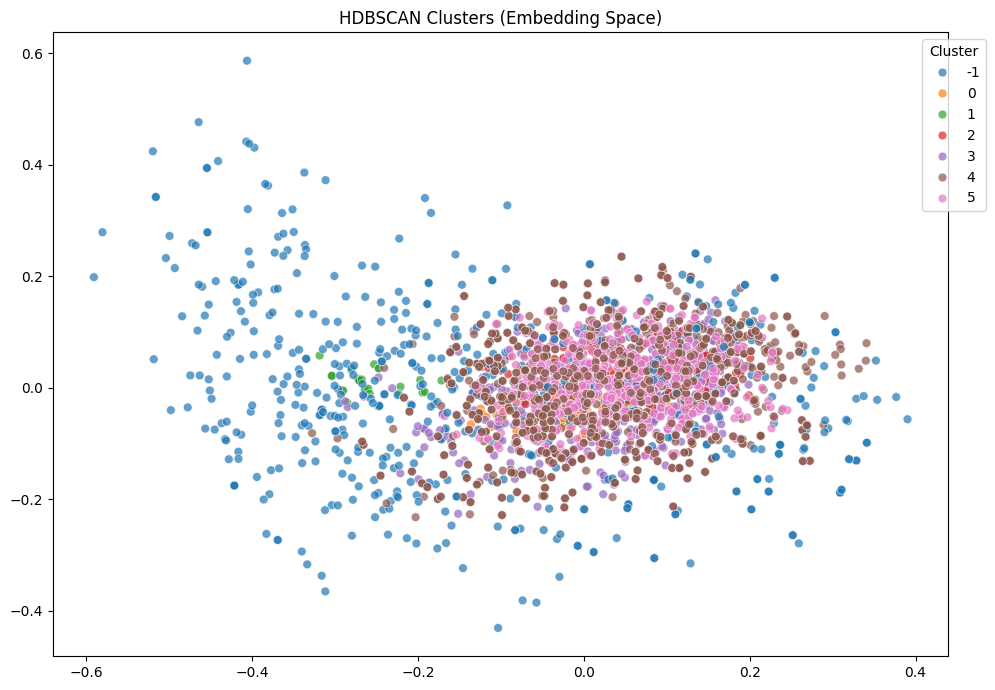

In [20]:
hdbscan_figures["hdbscan_clusters"]

In [21]:
hdbscan_metric_df

,hdbscan_cluster,count,mean,std,min,max,metric
0,-1,560,143.380357,300.058814,0.000000,3306.000000,bare_routed_2q
1,0,118,63.305085,12.449219,36.000000,90.000000,bare_routed_2q
2,1,28,35.428571,8.569665,23.000000,60.000000,bare_routed_2q
3,2,93,805.892473,566.355885,66.000000,2512.000000,bare_routed_2q
4,3,419,347.668258,197.104100,44.000000,828.000000,bare_routed_2q
5,4,1166,193.304460,81.774908,57.000000,507.000000,bare_routed_2q
6,5,443,177.799097,63.491709,57.000000,315.000000,bare_routed_2q
7,-1,560,288.682143,487.092479,4.000000,4819.000000,bare_routed_depth
8,0,118,96.491525,19.970810,57.000000,159.000000,bare_routed_depth
9,1,28,44.750000,11.017242,27.000000,79.000000,bare_routed_depth


## Interesting results for HDBSCAN on the lowest loss embedding

I'm wondering if the collapse to 2d for viewing is removing some ability to see the cluster seperation?

Regardless, these clusters do seem much more well seperated than the GMM clusters.

thoughts on the metric df:
1. noise cluster (-1): very spread out (2q: 0–3306, depth: 4–4819), so these are basically “doesn’t fit anywhere” circuits that don’t form a stable pattern in embedding space
2. cluster 0: fairly small circuits (~63 2q, ~96 depth) with tight spread, looks like a clean “small-to-mid” circuit group
3. cluster 1: very small and very consistent (~35 2q, ~45 depth), probably a distinct minimal-circuit regime
4. cluster 2: extreme large circuits (~806 2q, ~1516 depth) with high variance, clearly a high-complexity outlier-heavy group
5. cluster 3: large circuits (~347 2q, ~610 depth) that form a broad mid–high complexity band
6. cluster 4: medium circuits (~193 2q, ~346 depth), fairly stable and likely a “default” or common regime
7. cluster 5: slightly simpler medium group (~178 2q, ~327 depth), very close to cluster 4 but shifted lower in complexity
8. mirror_over_bare_2q (all clusters): basically flat across everything (~1.8–2.1), so it’s not really what’s driving the clustering — size and depth are doing most of the work

it looks like HDBSCAN is basically finding the “natural pockets” in the data and leaving everything else out as noise, so we got a few stable groups plus a clear set of outliers instead of everything being forces into a cluster.

Once again, this is just an example, we're going to run the full pipeline and get more meaningful figures and tables and run ARI after we have the three modeling functions

## Recap of behavior we saw from K-Means Clustering, GMM, and HDBSCAN

* KMeans is behaving like a coarse global partitioner, mainly splitting the dataset by circuit size/depth while ignoring finer structural or behavioral distinctions

* GMM is merging many of those overlapping groups into just two broad distributions because each Gaussian can now model correlations between features (especially routed 2Q count and depth).

* HDBSCAN is basically finding the “natural pockets” in the data and leaving everything else out as noise, so we got a few stable groups plus a clear set of outliers instead of everything being forces into a cluster.


Testing this behavior on a few other embedding files followed the same general patterns as above. It's interesting they have a niche they each fit into.

# Use ARI to determine which embedding the models agree 

To pull text back in from earlier, I think Adjusted Rand Index (ARI) would be a good method per sklearn (https://scikit-learn.org/stable/auto_examples/cluster/plot_adjusted_for_chance_measures.html) as it allows us to compare the similarity between clusterings, making it a robust and more reliable than raw accuracy-style comparisons for unsupervised clustering evaluation.

Here I believe we can use it to state which embedding the models agree on most strongly in terms of producing consistent cluster assignments across different clustering methods. This would effectively treat agreement in the structure as a proxy for how “well-formed” or separable the embedding space is. That means we could possibly learn something about the circuits from their QASM files without relying on manual feature engineering, instead using the consistency of unsupervised clustering results as a signal of underlying structure in the data.

In [31]:
import os
from pathlib import Path
import pandas as pd
pd.set_option("display.max_colwidth", None)

from sklearn.metrics import adjusted_rand_score

def run_unsupervised_learning_analysis(embedding_dir, csv_path, output_dir):
    """
    Runs kmeans, gmm, and hdbscan clustering pipelines across all embedding files
    in the given directory, computes pairwise ARI scores, and returns ranked results.

    Parameters
    ----------
    embedding_dir : str or Path
        Directory containing embedding CSV files.
    csv_path : str
        Path to the swap dataset CSV.
    output_dir : str
        Directory where per-embedding summaries will be saved.

    Returns
    -------
    comparison_df : pd.DataFrame
        Embeddings ranked by mean ARI agreement score across methods.
    final_results : pd.DataFrame
        Full cluster assignments for all embeddings.
    final_summaries : pd.DataFrame
        Per-method summaries for all embeddings.
    """

    embedding_dir = Path(embedding_dir)
    embedding_files = [f.name for f in embedding_dir.iterdir() if f.is_file()]

    os.makedirs(output_dir, exist_ok=True)

    all_comparisons = []
    all_results = []
    all_summaries = []

    for emb_file in embedding_files:
        embedding_path = os.path.join(embedding_dir, emb_file)

        print("\n######################################")
        print(f"Running pipelines for: {emb_file}")
        print("######################################\n")

        ###############################################
        # run clustering pipelines
        ###############################################
        kmeans_main, kmeans_out, kmeans_summary, kmeans_metric_df, kmeans_figures = run_kmeans_pipeline(
            csv_path, embedding_path
        )

        gmm_main, gmm_out, gmm_summary, gmm_metric_df, gmm_figures = run_gmm_pipeline(
            csv_path, embedding_path
        )

        hdbscan_main, hdbscan_out, hdbscan_summary, hdbscan_metric_df, hdbscan_figures = run_hdbscan_pipeline(
            csv_path, embedding_path
        )

        ###############################################
        # merge cluster assignments
        ###############################################
        results_df = kmeans_main[["file"]].copy()
        results_df["kmeans_cluster"] = kmeans_main["kmeans_cluster"]
        results_df["gmm_cluster"] = gmm_main["gmm_cluster"]
        results_df["hdbscan_cluster"] = hdbscan_main["hdbscan_cluster"]
        results_df["embedding_file"] = emb_file

        all_results.append(results_df)

        ###############################################
        # compute ari matrix
        ###############################################
        methods = ["kmeans", "gmm", "hdbscan"]
        ari_matrix = pd.DataFrame(index=methods, columns=methods, dtype=float)

        for a in methods:
            for b in methods:
                ari_matrix.loc[a, b] = adjusted_rand_score(
                    results_df[f"{a}_cluster"], results_df[f"{b}_cluster"]
                )

        print("\nARI Matrix:")
        print(ari_matrix)

        ###############################################
        # extract summary metrics
        ###############################################
        k_g = ari_matrix.loc["kmeans", "gmm"]
        k_h = ari_matrix.loc["kmeans", "hdbscan"]
        g_h = ari_matrix.loc["gmm", "hdbscan"]
        mean_score = (k_g + k_h + g_h) / 3

        all_comparisons.append({
            "embedding_file": emb_file,
            "mean_score": mean_score,
            "kmeans_vs_gmm": k_g,
            "kmeans_vs_hdbscan": k_h,
            "gmm_vs_hdbscan": g_h,
        })

        ###############################################
        # save per-embedding summary
        ###############################################
        summary_df = pd.concat([
            kmeans_summary.assign(method="kmeans", embedding=emb_file),
            gmm_summary.assign(method="gmm", embedding=emb_file),
            hdbscan_summary.assign(method="hdbscan", embedding=emb_file),
        ])

        summary_df.to_csv(os.path.join(output_dir, f"summary_{emb_file}.csv"), index=False)
        all_summaries.append(summary_df)

    ###############################################
    # global ranking
    ###############################################
    comparison_df = (
        pd.DataFrame(all_comparisons)
        .sort_values("mean_score", ascending=False)
        [["embedding_file", "mean_score", "kmeans_vs_gmm", "kmeans_vs_hdbscan", "gmm_vs_hdbscan"]]
    )

    final_results = pd.concat(all_results)
    final_summaries = pd.concat(all_summaries)

    print("\n######################################")
    print("=== EMBEDDING RANKING (BEST to WORST) ===")
    print("######################################\n")
    print(comparison_df)
    print("\n=== PIPELINE COMPLETE ===")
    print(f"Processed {len(embedding_files)} embedding files")
    print("\nTop-performing embedding:")
    print(comparison_df.iloc[0])

    return comparison_df, final_results, final_summaries

In [6]:
from pathlib import Path
notebook_dir = Path.cwd()

# EMBEDDING_DIR = (notebook_dir / "../../data/datasets/embedding_data/embeddings").resolve()
# )
# CSV_PATH = (notebook_dir / "../../data/datasets/train_swap_FakeBrisbane.csv").resolve()
# OUTPUT_DIR = (notebook_dir / "../../data/datasets/unsupervised_learning_results").resolve()

# comparison_df, final_results, final_summaries = run_experiment(
#     embedding_dir=EMBEDDING_DIR,
#     csv_path=CSV_PATH,
#     output_dir=OUTPUT_DIR
# )

# as these calculations can take a very long time, reading the results into the dfs with the same name and showing the script output below
BASE_PATH = (notebook_dir / "../../data/datasets/unsupervised_learning_results").resolve()

comparison_df = pd.read_csv(f"{BASE_PATH}/embedding_comparison_ranked.csv")
final_results = pd.read_csv(f"{BASE_PATH}/ALL_cluster_assignments.csv")
final_summaries = pd.read_csv(f"{BASE_PATH}/ALL_summary_comparison.csv")

As this can take a significant time to run, here are the results that get printed out:

```
######################################
Running pipelines for: gcn_aug_dropout_and_norm_with_improved_edges_training.csv
######################################


ARI Matrix:
           kmeans       gmm   hdbscan
kmeans   1.000000  0.047065  0.217036
gmm      0.047065  1.000000  0.204689
hdbscan  0.217036  0.204689  1.000000

######################################
Running pipelines for: gcn_aug_dropout_and_norm_embeddings.csv
######################################


ARI Matrix:
           kmeans      gmm   hdbscan
kmeans   1.000000  0.39274  0.830138
gmm      0.392740  1.00000  0.336950
hdbscan  0.830138  0.33695  1.000000

######################################
Running pipelines for: gat_aug_dropout_and_norm_embeddings.csv
######################################


ARI Matrix:
           kmeans       gmm  hdbscan
kmeans   1.000000  0.492827  0.80385
gmm      0.492827  1.000000  0.64485
hdbscan  0.803850  0.644850  1.00000

######################################
Running pipelines for: gat_aug_and_dropout_embeddings.csv
######################################


ARI Matrix:
           kmeans       gmm   hdbscan
kmeans   1.000000  0.416188  0.502665
gmm      0.416188  1.000000  0.480946
hdbscan  0.502665  0.480946  1.000000

######################################
Running pipelines for: graphsage_aug_and_dropout_embeddings.csv
######################################


ARI Matrix:
           kmeans       gmm   hdbscan
kmeans   1.000000  0.473775  0.533609
gmm      0.473775  1.000000  0.903075
hdbscan  0.533609  0.903075  1.000000

######################################
Running pipelines for: graphsage_aug_dropout_and_norm_with_improved_edges_training.csv
######################################


ARI Matrix:
           kmeans       gmm   hdbscan
kmeans   1.000000 -0.021786  0.034846
gmm     -0.021786  1.000000  0.323240
hdbscan  0.034846  0.323240  1.000000

######################################
Running pipelines for: graphsage_aug_dropout_and_norm_embeddings.csv
######################################


ARI Matrix:
           kmeans       gmm   hdbscan
kmeans   1.000000  0.140165  0.372430
gmm      0.140165  1.000000  0.452449
hdbscan  0.372430  0.452449  1.000000

######################################
Running pipelines for: gae_embeddings.csv
######################################


ARI Matrix:
           kmeans       gmm   hdbscan
kmeans   1.000000  0.918199  0.905257
gmm      0.918199  1.000000  0.848186
hdbscan  0.905257  0.848186  1.000000

######################################
Running pipelines for: gat_aug_dropout_and_norm_with_improved_edges_training.csv
######################################


ARI Matrix:
           kmeans       gmm   hdbscan
kmeans   1.000000  0.837898  0.393727
gmm      0.837898  1.000000  0.494050
hdbscan  0.393727  0.494050  1.000000

######################################
Running pipelines for: gcn_aug_and_dropout_embeddings.csv
######################################


ARI Matrix:
           kmeans       gmm   hdbscan
kmeans   1.000000  0.901529  0.042251
gmm      0.901529  1.000000  0.107953
hdbscan  0.042251  0.107953  1.000000

######################################
=== EMBEDDING RANKING (BEST to WORST) ===
######################################

                                                    embedding_file  mean_score  kmeans_vs_gmm  kmeans_vs_hdbscan  gmm_vs_hdbscan
7                                               gae_embeddings.csv    0.890547       0.918199           0.905257        0.848186
2                          gat_aug_dropout_and_norm_embeddings.csv    0.647176       0.492827           0.803850        0.644850
4                         graphsage_aug_and_dropout_embeddings.csv    0.636820       0.473775           0.533609        0.903075
8        gat_aug_dropout_and_norm_with_improved_edges_training.csv    0.575225       0.837898           0.393727        0.494050
1                          gcn_aug_dropout_and_norm_embeddings.csv    0.519943       0.392740           0.830138        0.336950
3                               gat_aug_and_dropout_embeddings.csv    0.466600       0.416188           0.502665        0.480946
9                               gcn_aug_and_dropout_embeddings.csv    0.350577       0.901529           0.042251        0.107953
6                    graphsage_aug_dropout_and_norm_embeddings.csv    0.321681       0.140165           0.372430        0.452449
0        gcn_aug_dropout_and_norm_with_improved_edges_training.csv    0.156263       0.047065           0.217036        0.204689
5  graphsage_aug_dropout_and_norm_with_improved_edges_training.csv    0.112100      -0.021786           0.034846        0.323240

=== PIPELINE COMPLETE ===
Processed 10 embedding files

Top-performing embedding:
embedding_file       gae_embeddings.csv
mean_score                     0.890547
kmeans_vs_gmm                  0.918199
kmeans_vs_hdbscan              0.905257
gmm_vs_hdbscan                 0.848186
Name: 7, dtype: object
```

In [89]:
comparison_df

,embedding_file,mean_score,kmeans_vs_gmm,kmeans_vs_hdbscan,gmm_vs_hdbscan
0,gae_embeddings.csv,0.890547,0.918199,0.905257,0.848186
1,gat_aug_dropout_and_norm_embeddings.csv,0.647176,0.492827,0.803850,0.644850
2,graphsage_aug_and_dropout_embeddings.csv,0.636820,0.473775,0.533609,0.903075
3,gat_aug_dropout_and_norm_with_improved_edges_t...,0.575225,0.837898,0.393727,0.494050
4,gcn_aug_dropout_and_norm_embeddings.csv,0.519943,0.392740,0.830138,0.336950
5,gat_aug_and_dropout_embeddings.csv,0.466600,0.416188,0.502665,0.480946
6,gcn_aug_and_dropout_embeddings.csv,0.350577,0.901529,0.042251,0.107953
7,graphsage_aug_dropout_and_norm_embeddings.csv,0.321681,0.140165,0.372430,0.452449
8,gcn_aug_dropout_and_norm_with_improved_edges_t...,0.156263,0.047065,0.217036,0.204689
9,graphsage_aug_dropout_and_norm_with_improved_e...,0.112100,-0.021786,0.034846,0.323240


In [8]:
print(comparison_df.iloc[0])

embedding_file       gae_embeddings.csv
mean_score                     0.890547
kmeans_vs_gmm                  0.918199
kmeans_vs_hdbscan              0.905257
gmm_vs_hdbscan                 0.848186
Name: 0, dtype: object


In [9]:
final_results

,file,kmeans_cluster,gmm_cluster,hdbscan_cluster,embedding_file
0,graphstate_indep_none_10_s0.qasm,9,1,0,gcn_aug_dropout_and_norm_with_improved_edges_t...
1,graphstate_indep_none_10_s1.qasm,9,1,0,gcn_aug_dropout_and_norm_with_improved_edges_t...
2,graphstate_indep_none_10_s10.qasm,9,1,0,gcn_aug_dropout_and_norm_with_improved_edges_t...
3,graphstate_indep_none_10_s11.qasm,9,1,0,gcn_aug_dropout_and_norm_with_improved_edges_t...
4,graphstate_indep_none_10_s12.qasm,9,1,0,gcn_aug_dropout_and_norm_with_improved_edges_t...
...,...,...,...,...,...
28265,vqe_two_local_indep_none_9_s5.qasm,0,0,-1,gcn_aug_and_dropout_embeddings.csv
28266,vqe_two_local_indep_none_9_s6.qasm,0,0,-1,gcn_aug_and_dropout_embeddings.csv
28267,vqe_two_local_indep_none_9_s7.qasm,0,0,18,gcn_aug_and_dropout_embeddings.csv
28268,vqe_two_local_indep_none_9_s8.qasm,0,0,19,gcn_aug_and_dropout_embeddings.csv


In [10]:
final_summaries

,best_k,silhouette,n_samples,n_features,pca_dims,method,embedding,bic,n_clusters,noise_points,noise_ratio
0,12.0,0.271580,2827,384,384.0,kmeans,gcn_aug_dropout_and_norm_with_improved_edges_t...,NaN,NaN,NaN,NaN
1,2.0,0.198466,2827,384,384.0,gmm,gcn_aug_dropout_and_norm_with_improved_edges_t...,-1.118503e+07,NaN,NaN,NaN
2,NaN,NaN,2827,384,NaN,hdbscan,gcn_aug_dropout_and_norm_with_improved_edges_t...,NaN,13.0,221.0,0.078175
3,5.0,0.645933,2827,384,384.0,kmeans,gcn_aug_dropout_and_norm_embeddings.csv,NaN,NaN,NaN,NaN
4,2.0,0.488427,2827,384,384.0,gmm,gcn_aug_dropout_and_norm_embeddings.csv,-1.157416e+07,NaN,NaN,NaN
5,NaN,NaN,2827,384,NaN,hdbscan,gcn_aug_dropout_and_norm_embeddings.csv,NaN,6.0,9.0,0.003184
6,5.0,0.500985,2827,384,384.0,kmeans,gat_aug_dropout_and_norm_embeddings.csv,NaN,NaN,NaN,NaN
7,2.0,0.271649,2827,384,384.0,gmm,gat_aug_dropout_and_norm_embeddings.csv,-1.151533e+07,NaN,NaN,NaN
8,NaN,NaN,2827,384,NaN,hdbscan,gat_aug_dropout_and_norm_embeddings.csv,NaN,7.0,142.0,0.050230
9,5.0,0.604116,2827,128,128.0,kmeans,gat_aug_and_dropout_embeddings.csv,NaN,NaN,NaN,NaN


# Look at run results
The full run took a while, but what's it telling us?

* First, it outputs (these are all saved to files for later use) the individual ARI for each embedding file between kmeans, GMM, and hdbscan.
* Then it summarizes the results
* Finally, it shows us the results of the embedding that ARI says kmeans, gmm, and hdbscan agree on

These results are not what I expected. I had expected what I thought were the most well put together graphs (method_aug_dropout_and_norm_with_improved_edges_training), having the most information contained in the graphs, to have the highest agreement, but that's not the case, the most simple setup, the GAE, won out.

The final_summaries table is basically giving us a single view of how all the embeddings behave across KMeans, GMM, and HDBSCAN at the same time. It brings together the internal clustering metrics (like silhouette score and BIC) along with structural outputs from HDBSCAN (like number of clusters and noise ratio), so we can more directly compare how each embedding behaves under very different clustering assumptions.

What it’s really showing is that clustering performance is driven much more by the embedding itself than by the clustering method we apply. Some embeddings consistently produce cleaner structure across all methods (`gae`, `gat_aug_and_dropout`, and `graphsage_aug_and_dropout`), while others are unstable regardless of which clustering algorithm is used (`graphsage_aug_dropout_and_norm_with_improved_edges`, `gcn_aug_dropout_and_norm_with_improved_edges_training`, `gcn_aug_and_dropout`, and `graphsage_aug_dropout_and_norm`). In general, the stronger embeddings tend to show higher silhouette scores and more consistent clustering structure, while weaker ones produce noisier partitions and more variation in cluster counts and density-based assignments.

One thing that stands out is the spread in behavior across embeddings: some naturally fall into clearer groupings, while others don’t separate as cleanly no matter what clustering method is used.

Given this information, let’s make two plots: a heatmap of the ARI results, so we can easily see where the models agree and disagree across embeddings, and a sensitivity plot using the HDBSCAN data to check how stable each embedding is when we change the density-based clustering assumptions. The idea is that the heatmap highlights which embeddings produce consistent structure across KMeans, GMM, and HDBSCAN, while the sensitivity plot shows whether that structure holds up or breaks down under different parameter settings.

Loading from: /Users/steventf/Documents/GitHub/SIADS696_circuit_swaps_and_polarization/data/datasets/unsupervised_learning_results
Found 10 files:


/var/folders/_5/bz1j148d10xdhksjb4dm4lth0000gp/T/ipykernel_68009/1502753904.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar


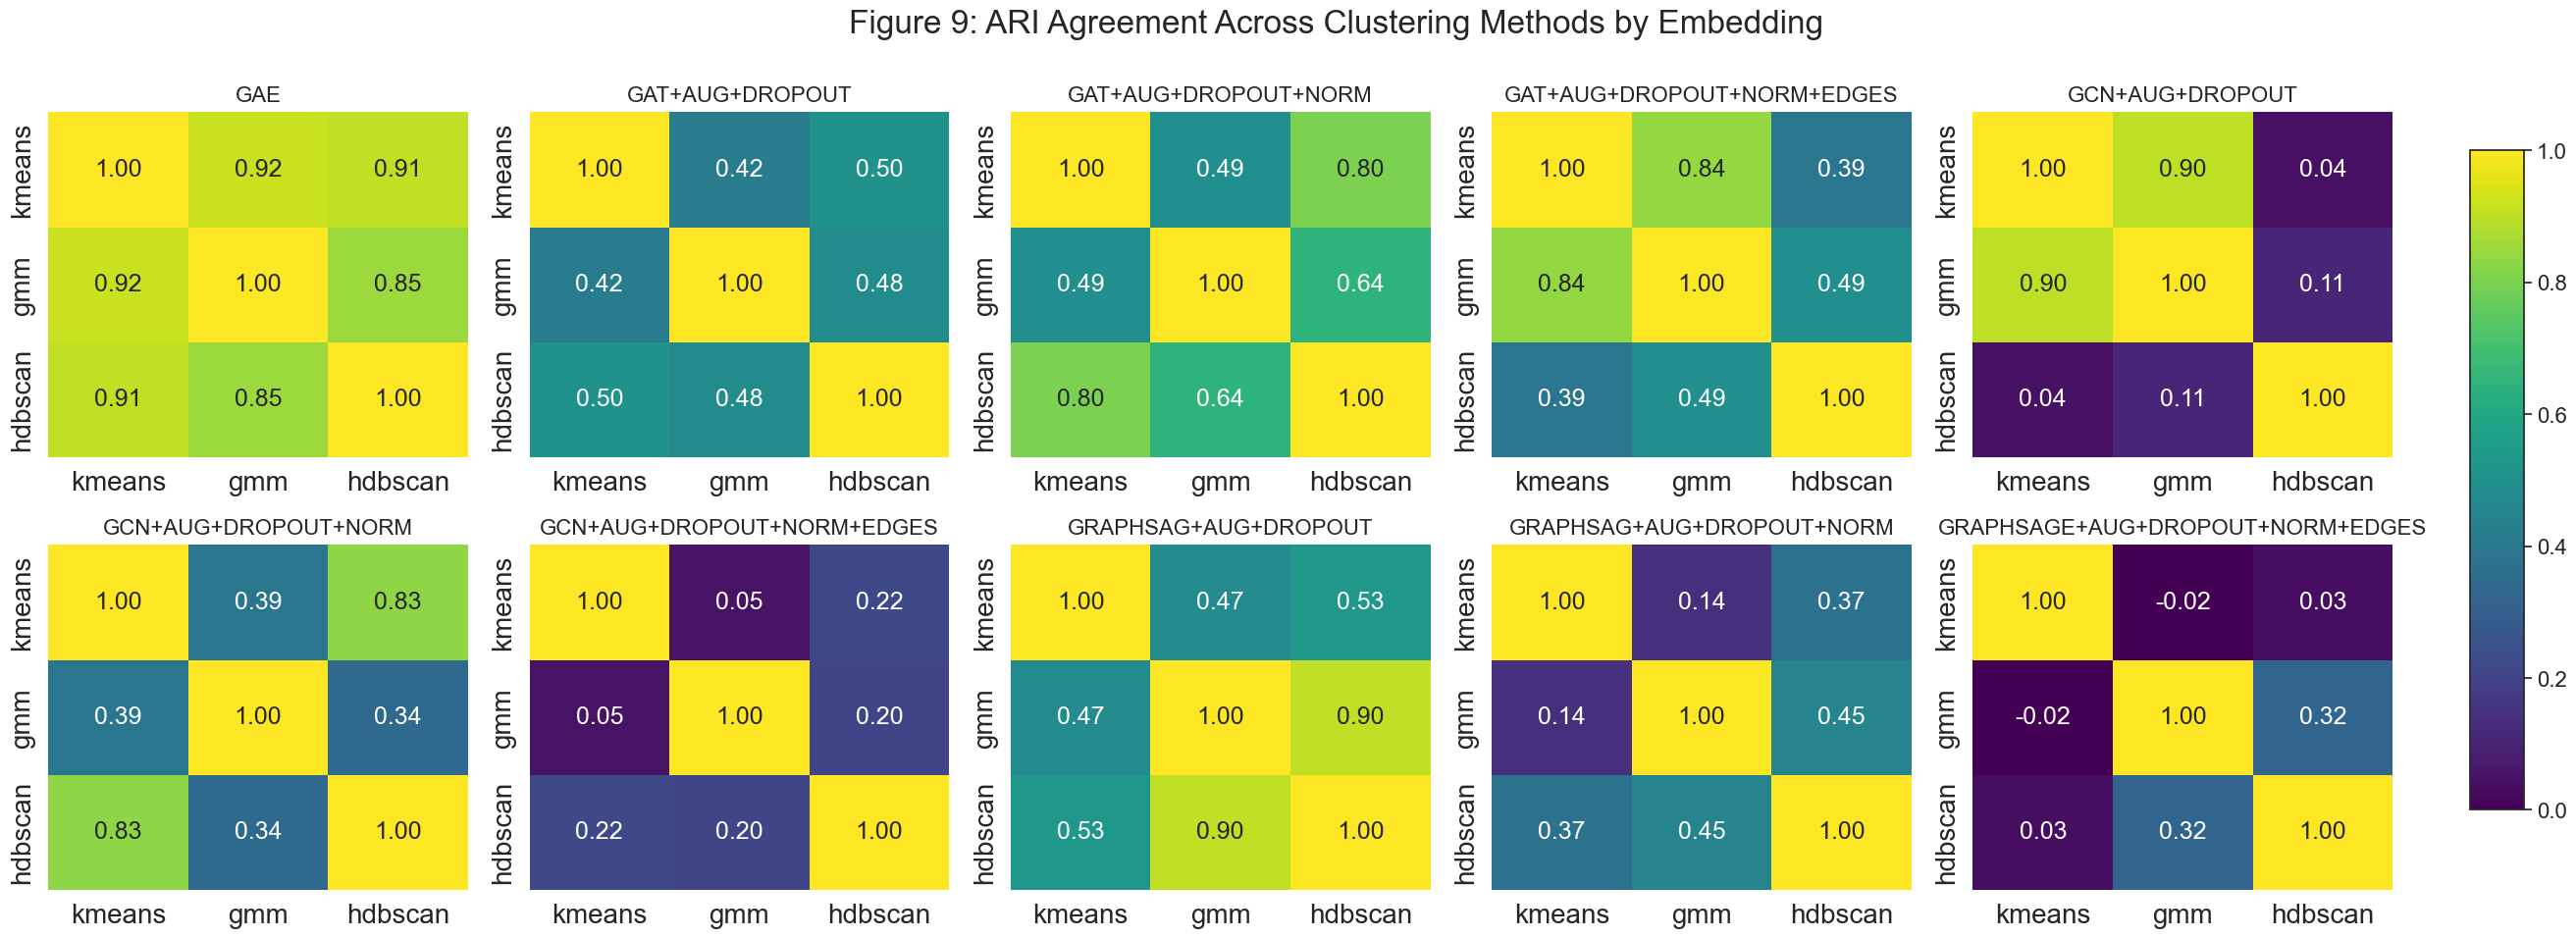

In [67]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

###############################################
# like in the code blocks above, set the path, so ipynb can find the files
###############################################
notebook_dir = Path.cwd()
ari_file_path = (notebook_dir / "../../data/datasets/unsupervised_learning_results").resolve()

#print("Loading from:", ari_file_path)

###############################################
# read in all the ARI files
###############################################
ari_files = sorted(ari_file_path.glob("ari_matrix_*.csv"))

# if len(ari_files) == 0:
#     raise FileNotFoundError(f"No ARI files found in {ari_file_path}")

# print(f"Found {len(ari_files)} files:")

###############################################
# create a seaborn scaffolding, 5 cols, 2 rows
###############################################
sns.set(style="white", font_scale=1.3)

cols = 5
rows = (len(ari_files) + cols - 1) // cols

# probably too much time messing with figsizes, but these work well
fig, axes = plt.subplots(rows, cols, figsize=(5.5 * cols, 4.8 * rows))
axes = axes.flatten()

###############################################
# 4. create a seaborn plot of the ARI heatmap for each ARI file with unified colors
###############################################
mappable = None

for i, file in enumerate(ari_files):
    df = pd.read_csv(file, index_col=0)

    ax = axes[i]
    hm = sns.heatmap(
        df,
        ax=ax,
        cmap="viridis",
        vmin=0,
        vmax=1,
        annot=True,
        fmt=".2f",
        cbar=False,   # disable per-plot colorbars
        annot_kws={"size": 18}
    )

    if mappable is None:
        mappable = hm.collections[0]

    # file names too long, so I added a label map
    label_map = {
        "gae_embeddings": "GAE",
        "gcn_aug_and_dropout_embeddings": "GCN+AUG+DROPOUT",
        "gcn_aug_dropout_and_norm_embeddings": "GCN+AUG+DROPOUT+NORM",
        "gcn_aug_dropout_and_norm_with_improved_edges_training":"GCN+AUG+DROPOUT+NORM+EDGES",
        "gat_aug_and_dropout_embeddings":"GAT+AUG+DROPOUT",
        "gat_aug_dropout_and_norm_embeddings":"GAT+AUG+DROPOUT+NORM",
        "gat_aug_dropout_and_norm_with_improved_edges_training":"GAT+AUG+DROPOUT+NORM+EDGES",
        "graphsage_aug_and_dropout_embeddings":"GRAPHSAG+AUG+DROPOUT",
        "graphsage_aug_dropout_and_norm_embeddings":"GRAPHSAG+AUG+DROPOUT+NORM",
        "graphsage_aug_dropout_and_norm_with_improved_edges_training":"GRAPHSAGE+AUG+DROPOUT+NORM+EDGES"
    }

    key = file.stem.replace("ari_matrix_", "")
    title = label_map.get(key, key)
    #title = file.stem.replace("ari_matrix_", "")
    ax.set_title(title, fontsize=16, pad=8)

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.tick_params(axis='both', labelsize=20)

###############################################
# add color bar for the legend on the right side, roughly centerd
###############################################
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(mappable, cax=cbar_ax)
cbar.ax.tick_params(labelsize=16)

###############################################
# plot the final layout and add the figure title
###############################################
plt.suptitle(
    "Figure 9: ARI Agreement Across Clustering Methods by Embedding",
    y=1.00,
    fontsize=24
)

# adjust slightly, so color bar isn't cut off
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

/var/folders/_5/bz1j148d10xdhksjb4dm4lth0000gp/T/ipykernel_68009/1706200369.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


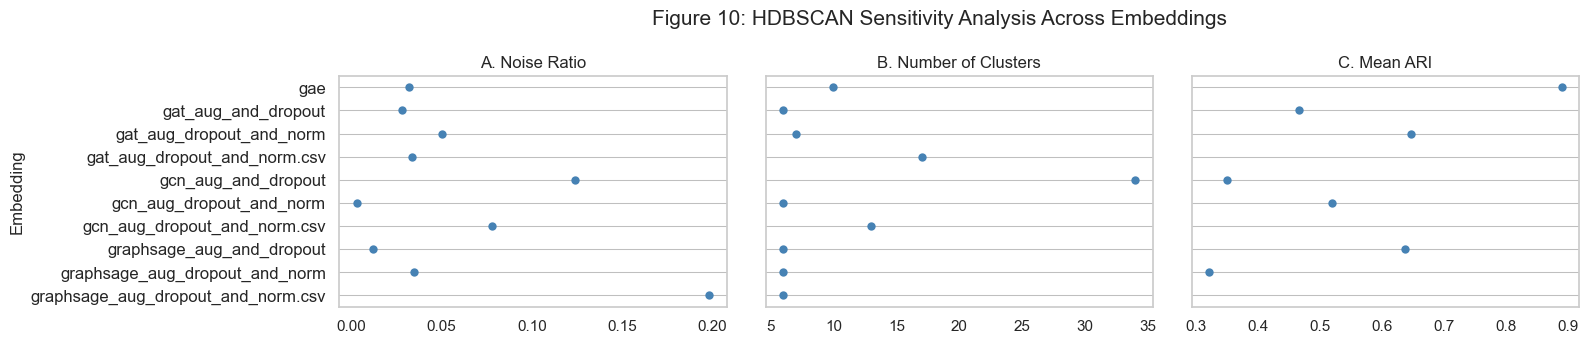

In [88]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

###############################################
# 1. use the final_summaries df to grab the HDBSCAN info
###############################################
hdbscan_df = final_summaries[final_summaries["method"] == "hdbscan"].copy()

# shorten the embedding names
hdbscan_df["embedding_clean"] = (
    hdbscan_df["embedding"]
    .str.replace("_embeddings.csv", "", regex=False)
    .str.replace("_with_improved_edges_training", "", regex=False)
)

###############################################
# use the comparison_df to pull in the mean ARI score
###############################################
mean_lookup = comparison_df[["embedding_file", "mean_score"]].copy()

# align the embedding name
mean_lookup["embedding_clean"] = (
    mean_lookup["embedding_file"]
    .str.replace("_embeddings.csv", "", regex=False)
)

###############################################
# merge the information together
###############################################
hdbscan_df = hdbscan_df.merge(
    mean_lookup[["embedding_clean", "mean_score"]],
    on="embedding_clean",
    how="left"
)

###############################################
# sort the df by embedding type
###############################################
order = sorted(hdbscan_df["embedding_clean"].unique())

###############################################
# create a seaborn scaffolding, 3 cols, 1 rows
###############################################
sns.set(style="whitegrid", font_scale=1.0)

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 3),
    sharey=True,
    # seperate them just a little bit
    gridspec_kw={"wspace": 0.1}
)

###############################################
# A. Noise Ratio
###############################################
sns.stripplot(
    data=hdbscan_df,
    x="noise_ratio",
    y="embedding_clean",
    order=order,
    ax=axes[0],
    color="steelblue",
    size=6
)

axes[0].set_title("A. Noise Ratio")
axes[0].set_xlabel("")
axes[0].set_ylabel("Embedding")
# only present on this one, hide on others
axes[0].tick_params(axis="y", labelsize=12)

###############################################
# B. Number of Clusters
###############################################
sns.stripplot(
    data=hdbscan_df,
    x="n_clusters",
    y="embedding_clean",
    order=order,
    ax=axes[1],
    color="steelblue",
    size=6
)

axes[1].set_title("B. Number of Clusters")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", left=False, labelleft=False)

###############################################
# C. Cross-Method Agreement
###############################################
sns.stripplot(
    data=hdbscan_df,
    x="mean_score",
    y="embedding_clean",
    order=order,
    ax=axes[2],
    color="steelblue",
    size=6
)

axes[2].set_title("C. Mean ARI")
axes[2].set_xlabel("")
axes[2].set_ylabel("")
axes[2].tick_params(axis="y", left=False, labelleft=False)

###############################################
# Add horizontal guide lines, so we can follow the embeddings accross
# figure title and display
###############################################
for ax in axes:
    ax.set_axisbelow(True)

    # light horizontal lines at every embedding
    ax.yaxis.grid(True, color="0.75", linewidth=0.75)

    # optional: remove vertical grid
    ax.xaxis.grid(False)

plt.suptitle(
    "Figure 10: HDBSCAN Sensitivity Analysis Across Embeddings",
    fontsize=15,
    y=1.10
)

plt.tight_layout()
plt.show()